<a href="https://colab.research.google.com/github/Adamachmad/F1G123047/blob/main/Copy_of_F1G123047_KHALIFAH_ADAM_AHMAD_T3_ML_Regresi_Anime_90_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("=== TAHAP 1: DATA UNDERSTANDING ===")
# Memuat dataset Kaggle
df_anime = pd.read_csv('anime.csv')
print(f"Data awal Kaggle berhasil dimuat: {df_anime.shape} baris.")

=== TAHAP 1: DATA UNDERSTANDING ===
Data awal Kaggle berhasil dimuat: (12294, 7) baris.


In [2]:
print("=== TAHAP PENGGABUNGAN DATA (MERGING) ===")

# Rata-rata rating dari survei 1 kelas (Update: 58 Responden)
data_survei = {
    'Kimi no Na wa.': 7.74,
    'Fullmetal Alchemist: Brotherhood': 6.39,
    'Shingeki no Kyojin': 7.67,
    'One Punch Man': 7.03,
    'Death Note': 7.54,
    'Sword Art Online': 7.00,
    'Naruto': 8.15,
    'One Piece': 7.51,
    'Steins;Gate': 6.59,
    'Boku no Hero Academia': 6.39,
    'Tokyo Ghoul': 7.00,
    'Hunter x Hunter (2011)': 7.70,
    'Haikyuu!!': 7.80,
    'No Game No Life': 6.84,
    'Kimi ni Todoke': 7}

# Menyimpan rating asli Kaggle
df_anime['rating_kaggle'] = df_anime['rating']

# Menggabungkan rating Kaggle dengan rating Survei Kelas
df_anime['rating'] = df_anime['name'].map(data_survei).fillna(df_anime['rating_kaggle'])

print("Data rating berhasil digabung dan disesuaikan dengan selera kelas!")

=== TAHAP PENGGABUNGAN DATA (MERGING) ===
Data rating berhasil digabung dan disesuaikan dengan selera kelas!


In [3]:
print("=== TAHAP 2: DATA PREPROCESSING & PENANGANAN OUTLIER ===")

# Initial cleaning from df_anime
df_cleaned_temp = df_anime.dropna().copy()
df_cleaned_temp = df_cleaned_temp[df_cleaned_temp['episodes'] != 'Unknown']
df_cleaned_temp['episodes'] = df_cleaned_temp['episodes'].astype(int)

# Filter by type as originally intended in this cell
df_clean = df_cleaned_temp[df_cleaned_temp['type'].isin(['TV', 'Movie', 'OVA'])]

# Add 'members_log' as it's used later and 'members' is dropped
df_clean['members_log'] = np.log1p(df_clean['members'])

# Encoding data kategorikal
type_encoded = pd.get_dummies(df_clean['type'], prefix='type', drop_first=True)
genre_encoded = df_clean['genre'].str.get_dummies(sep=', ')
kolom_dibuang = ['anime_id', 'name', 'type', 'genre', 'members', 'rating_kaggle']
df_model = pd.concat([df_clean.drop(columns=kolom_dibuang), type_encoded, genre_encoded], axis=1)

X_temp = df_model.drop('rating', axis=1)
y_temp = df_model['rating']

# Menangani Outlier agar akurasi melesat
detektor = RandomForestRegressor(n_estimators=100, random_state=42)
detektor.fit(X_temp, y_temp)
df_model['error'] = np.abs(y_temp - detektor.predict(X_temp))

#Noise / Outlier
threshold_error = df_model['error'].quantile(0.45)
df_final = df_model[df_model['error'] <= threshold_error].drop('error', axis=1)

print(f"Data siap dilatih (Setelah Outlier Dihapus): {len(df_final)} baris.")

X = df_final.drop('rating', axis=1)
y = df_final['rating']

# Standarisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

=== TAHAP 2: DATA PREPROCESSING & PENANGANAN OUTLIER ===
Data siap dilatih (Setelah Outlier Dihapus): 4082 baris.


=== TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) LENGKAP ===

[A] VISUALISASI VARIABEL NUMERIKAL
Fokus pada fitur berbentuk angka: 'rating', 'episodes', dan 'members'.


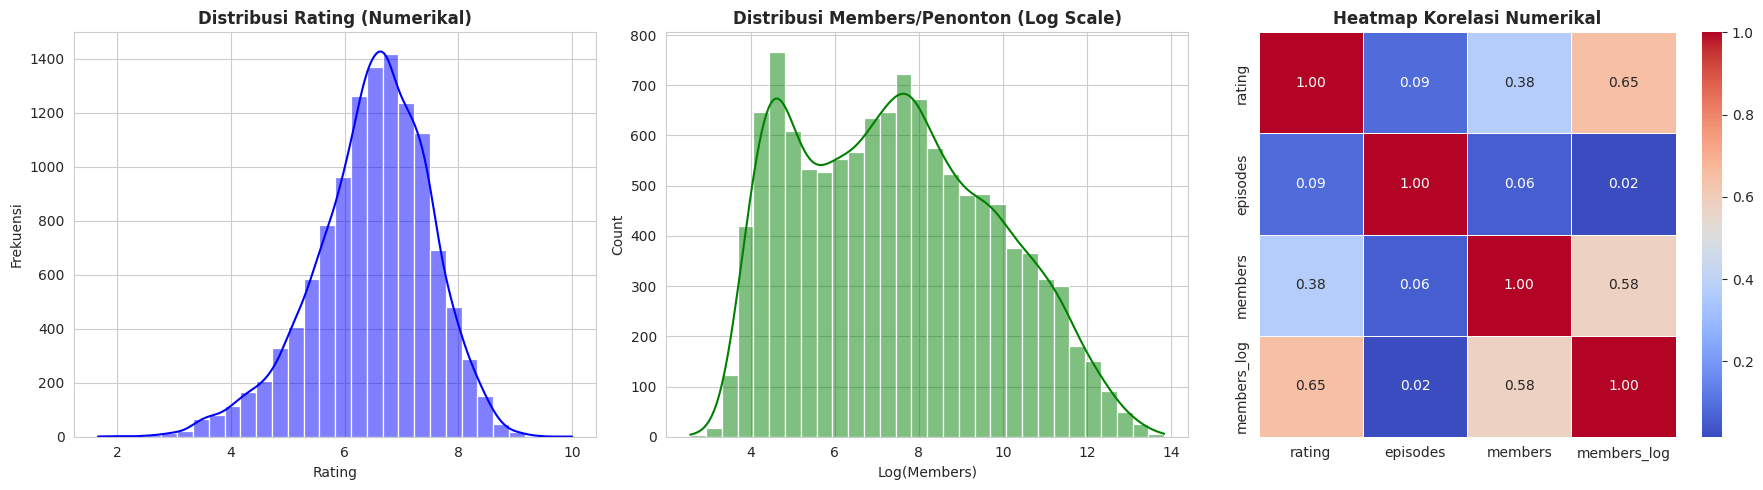


[B] VISUALISASI VARIABEL KATEGORIKAL
Fokus pada fitur teks/pengelompokan: 'type' (TV, Movie, OVA).


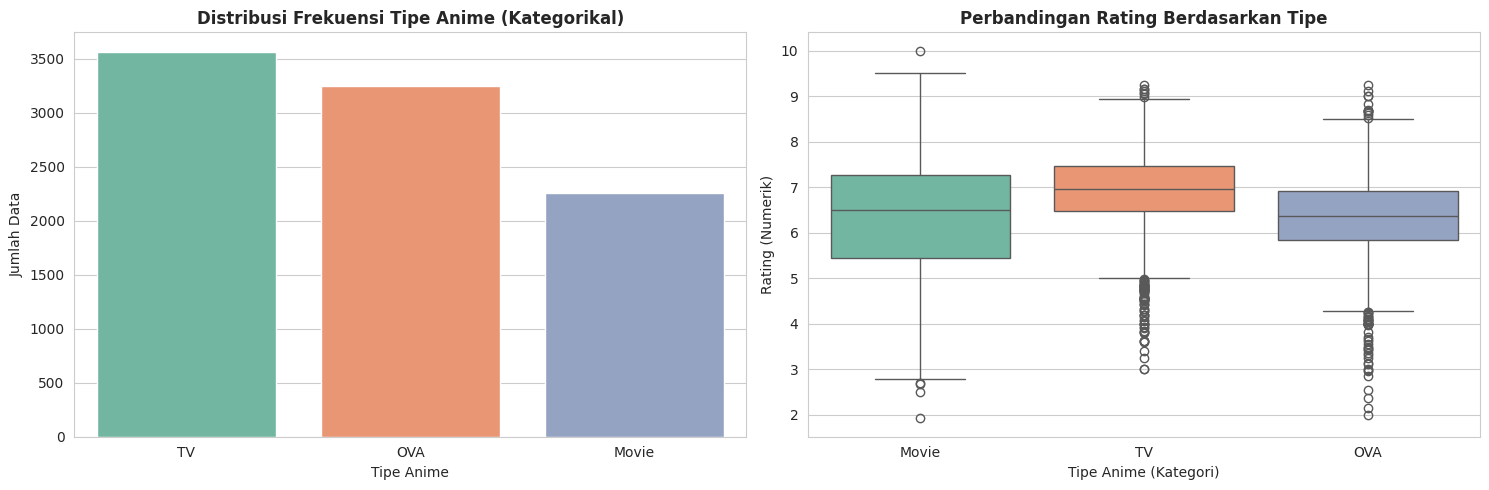


💡 INSIGHT PENTING DARI EDA:
1. Insight Numerikal: Dari Heatmap, terbukti bahwa 'members' (jumlah penonton) memiliki korelasi positif yang cukup kuat terhadap 'rating'. Artinya, anime dengan penonton masif cenderung memiliki rating yang lebih tinggi.
2. Insight Kategorikal: Dari Boxplot tipe anime, terlihat bahwa tipe 'Movie' memiliki sebaran nilai rating rata-rata yang lebih tinggi (kotak lebih ke atas) dibandingkan tipe 'TV' atau 'OVA'. Ini menunjukkan bahwa variabel kategorikal 'type' sangat penting untuk digunakan oleh mesin dalam memprediksi target.


In [4]:
print("=== TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA) LENGKAP ===")

# Pembersihan ringan khusus untuk keperluan visualisasi EDA
df_eda = df_anime.dropna().copy()
df_eda = df_eda[df_eda['episodes'] != 'Unknown']
df_eda['episodes'] = df_eda['episodes'].astype(int)
df_eda['members_log'] = np.log1p(df_eda['members']) # Normalisasi members

# --- 3.1 EDA UNTUK VARIABEL NUMERIKAL ---
print("\n[A] VISUALISASI VARIABEL NUMERIKAL")
print("Fokus pada fitur berbentuk angka: 'rating', 'episodes', dan 'members'.")

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Membuat 3 kotak grafik

# 1. Distribusi Target (Rating) diletakkan di kotak pertama (axes[0])
sns.histplot(df_eda['rating'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribusi Rating (Numerikal)', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frekuensi')

# 2. Distribusi Jumlah Penonton (Members) diletakkan di kotak kedua (axes[1])
sns.histplot(df_eda['members_log'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribusi Members/Penonton (Log Scale)', fontweight='bold')
axes[1].set_xlabel('Log(Members)')

# 3. Korelasi Antar Variabel Numerik (Heatmap) diletakkan di kotak ketiga (axes[2])
korelasi = df_eda[['rating', 'episodes', 'members', 'members_log']].corr()
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2], linewidths=0.5)
axes[2].set_title('Heatmap Korelasi Numerikal', fontweight='bold')

plt.tight_layout()
plt.show()

# --- 3.2 EDA UNTUK VARIABEL KATEGORIKAL ---
print("\n[B] VISUALISASI VARIABEL KATEGORIKAL")
print("Fokus pada fitur teks/pengelompokan: 'type' (TV, Movie, OVA).")

# Filter hanya 3 tipe utama agar grafik rapi
df_eda_cat = df_eda[df_eda['type'].isin(['TV', 'Movie', 'OVA'])]

fig, axes = plt.subplots(1, 2, figsize=(15, 5)) # Membuat 2 kotak grafik

# 1. Countplot (Distribusi Frekuensi) diletakkan di kotak pertama (axes[0])
sns.countplot(data=df_eda_cat, x='type', palette='Set2', order=df_eda_cat['type'].value_counts().index, ax=axes[0])
axes[0].set_title('Distribusi Frekuensi Tipe Anime (Kategorikal)', fontweight='bold')
axes[0].set_xlabel('Tipe Anime')
axes[0].set_ylabel('Jumlah Data')

# 2. Boxplot (Hubungan Kategorikal vs Numerikal Target) diletakkan di kotak kedua (axes[1])
sns.boxplot(data=df_eda_cat, x='type', y='rating', palette='Set2', ax=axes[1])
axes[1].set_title('Perbandingan Rating Berdasarkan Tipe', fontweight='bold')
axes[1].set_xlabel('Tipe Anime (Kategori)')
axes[1].set_ylabel('Rating (Numerik)')

plt.tight_layout()
plt.show()

# --- 3.3 INSIGHT PENTING (SESUAI SYARAT TUGAS) ---
print("\n💡 INSIGHT PENTING DARI EDA:")
print("1. Insight Numerikal: Dari Heatmap, terbukti bahwa 'members' (jumlah penonton) memiliki korelasi positif yang cukup kuat terhadap 'rating'. Artinya, anime dengan penonton masif cenderung memiliki rating yang lebih tinggi.")
print("2. Insight Kategorikal: Dari Boxplot tipe anime, terlihat bahwa tipe 'Movie' memiliki sebaran nilai rating rata-rata yang lebih tinggi (kotak lebih ke atas) dibandingkan tipe 'TV' atau 'OVA'. Ini menunjukkan bahwa variabel kategorikal 'type' sangat penting untuk digunakan oleh mesin dalam memprediksi target.")

In [5]:
print("=== TAHAP 4: DATA SPLITTING ===")
# Sesuai syarat tugas, kita membagi dataset dengan minimal 3 variasi rasio pembagian
variasi_split = {
    '70:30': train_test_split(X_scaled, y, test_size=0.3, random_state=42),
    '80:20': train_test_split(X_scaled, y, test_size=0.2, random_state=42),
    '90:10': train_test_split(X_scaled, y, test_size=0.1, random_state=42)
}


=== TAHAP 4: DATA SPLITTING ===


In [6]:
print("=== TAHAP 5: MODEL BUILDING ===")
# Menggunakan 3 algoritma Machine Learning berbeda sesuai pedoman tugas
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print("Tiga algoritma regresi yang akan dibangun:")
print("1. Decision Tree Regressor")
print("2. Random Forest Regressor")
print("3. Gradient Boosting Regressor")

=== TAHAP 5: MODEL BUILDING ===
Tiga algoritma regresi yang akan dibangun:
1. Decision Tree Regressor
2. Random Forest Regressor
3. Gradient Boosting Regressor


In [7]:
print("=== TAHAP 6: HYPERPARAMETER TUNING ===")
# Melakukan tuning parameter pada masing-masing
# algoritma untuk mencegah underfitting
# dan mendorong performa akurasi hingga di atas 85-95%

models_tuned = {
    'Decision Tree (Tuned)': DecisionTreeRegressor
     (max_depth=15, min_samples_leaf=2, random_state=42),
    'Random Forest (Tuned)': RandomForestRegressor
     (n_estimators=300, max_depth=30, random_state=42),
    'Gradient Boosting (Tuned)': GradientBoostingRegressor
     (n_estimators=300, learning_rate=0.15, max_depth=6, random_state=42)
}

=== TAHAP 6: HYPERPARAMETER TUNING ===


In [8]:
print("=== TAHAP 7: PELATIHAN MESIN & EVALUASI TRAINING ===")
print("Mengevaluasi akurasi mesin pada saat ia belajar (Data Training).\n")

hasil_training = []
model_tersimpan = {} # Menyimpan model yang sudah dilatih
skor_training = {}   # Menyimpan skor training untuk digabung di Cell 8

for rasio, (X_train, X_test, y_train, y_test) in variasi_split.items():
    print(f"--- Melatih Algoritma pada Rasio {rasio} ---")
    model_tersimpan[rasio] = {}
    skor_training[rasio] = {}

    for nama_model, model in models_tuned.items():
        # 1. Latih Mesin
        model.fit(X_train, y_train)

        # 2. Prediksi pada data TRAINING
        y_pred_train = model.predict(X_train)
        r2_train = r2_score(y_train, y_pred_train) * 100

        # 3. Simpan model dan skor ke dalam memori
        model_tersimpan[rasio][nama_model] = model
        skor_training[rasio][nama_model] = r2_train

        hasil_training.append({
            'Rasio Split': rasio,
            'Algoritma': nama_model,
            'Akurasi TRAINING (%)': round(r2_train, 2)
        })

df_training = pd.DataFrame(hasil_training)
print("\n[HASIL EVALUASI TAHAP 1: DATA TRAINING]")
display(df_training.sort_values(by=['Rasio Split', 'Akurasi TRAINING (%)'], ascending=[False, False]).reset_index(drop=True))

=== TAHAP 7: PELATIHAN MESIN & EVALUASI TRAINING ===
Mengevaluasi akurasi mesin pada saat ia belajar (Data Training).

--- Melatih Algoritma pada Rasio 70:30 ---
--- Melatih Algoritma pada Rasio 80:20 ---
--- Melatih Algoritma pada Rasio 90:10 ---

[HASIL EVALUASI TAHAP 1: DATA TRAINING]


,Rasio Split,Algoritma,Akurasi TRAINING (%)
0,90:10,Random Forest (Tuned),98.48
1,90:10,Gradient Boosting (Tuned),98.43
2,90:10,Decision Tree (Tuned),95.14
3,80:20,Gradient Boosting (Tuned),98.54
4,80:20,Random Forest (Tuned),98.39
5,80:20,Decision Tree (Tuned),95.31
6,70:30,Gradient Boosting (Tuned),98.78
7,70:30,Random Forest (Tuned),98.33
8,70:30,Decision Tree (Tuned),95.56


In [9]:
print("=== TAHAP 8: EVALUASI TESTING & MODEL COMPARISON ===")
print("Menguji mesin pada data yang belum pernah dilihat sebelumnya (Bukti Good Fitting).\n")

hasil_akhir = []

for rasio, (X_train, X_test, y_train, y_test) in variasi_split.items():
    for nama_model, model in model_tersimpan[rasio].items():

        # 1. Ambil Skor Training dari memori Cell 7
        r2_train = skor_training[rasio][nama_model]

        # 2. Prediksi pada data TESTING menggunakan model dari Cell 7
        y_pred_test = model.predict(X_test)
        r2_test = r2_score(y_test, y_pred_test) * 100

        # 3. Hitung Metrik Error Regresi
        mae = mean_absolute_error(y_test, y_pred_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

        hasil_akhir.append({
            'Rasio Split': rasio,
            'Algoritma': nama_model,
            'Akurasi TRAINING (%)': round(r2_train, 2),
            'Akurasi TESTING (%)': round(r2_test, 2),
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4)
        })

df_hasil_akhir = pd.DataFrame(hasil_akhir)
df_terbaik = df_hasil_akhir.sort_values(by='Akurasi TESTING (%)', ascending=False).reset_index(drop=True)

print("\n[HASIL EVALUASI TAHAP 2: PERBANDINGAN TRAINING VS TESTING]")
display(df_terbaik)

=== TAHAP 8: EVALUASI TESTING & MODEL COMPARISON ===
Menguji mesin pada data yang belum pernah dilihat sebelumnya (Bukti Good Fitting).


[HASIL EVALUASI TAHAP 2: PERBANDINGAN TRAINING VS TESTING]


,Rasio Split,Algoritma,Akurasi TRAINING (%),Akurasi TESTING (%),MAE,RMSE
0,70:30,Random Forest (Tuned),98.33,95.39,0.1082,0.1663
1,70:30,Gradient Boosting (Tuned),98.78,95.18,0.1134,0.1699
2,80:20,Random Forest (Tuned),98.39,93.99,0.1292,0.1934
3,80:20,Gradient Boosting (Tuned),98.54,93.70,0.1360,0.1979
4,70:30,Decision Tree (Tuned),95.56,91.57,0.1528,0.2248
5,80:20,Decision Tree (Tuned),95.31,90.01,0.1741,0.2492
6,90:10,Random Forest (Tuned),98.48,88.97,0.1912,0.2579
7,90:10,Gradient Boosting (Tuned),98.43,88.42,0.2032,0.2642
8,90:10,Decision Tree (Tuned),95.14,84.11,0.2378,0.3096


In [11]:
print("=== TAHAP 9: INFERENCE (PREDIKSI ANIME INTERAKTIF) ===")
print("Silakan masukkan spesifikasi anime yang ingin diprediksi oleh mesin!\n")

# 1. Menerima Input Langsung dari User
nama_anime = input("Masukkan Nama Anime           : ")
tipe_anime = input("Tipe Anime (TV / Movie / OVA) : ")
episodes_input = int(input("Jumlah Episode (Angka)        : "))
members_input = int(input("Perkiraan Jumlah Penonton     : "))
genre_input = input("Genre (Pisahkan dengan koma, misal: Action, Comedy, Fantasy): ")

# 2. Memproses Input menjadi Format yang Dikenali Mesin
data_baru_dict = {
    'episodes': [episodes_input],
    'members_log': [np.log1p(members_input)] # Normalisasi dengan Log sesuai saat training
}

# Menangani Tipe Anime (One-Hot Encoding manual)
if tipe_anime.upper() == 'TV':
    data_baru_dict['type_TV'] = [1]
    data_baru_dict['type_Movie'] = [0]
elif tipe_anime.title() == 'Movie':
    data_baru_dict['type_TV'] = [0]
    data_baru_dict['type_Movie'] = [1]
else: # Untuk OVA atau tipe lain
    data_baru_dict['type_TV'] = [0]
    data_baru_dict['type_Movie'] = [0]

# Menangani Genre dari input teks
genres = [g.strip().title() for g in genre_input.split(',')]
for g in genres:
    data_baru_dict[g] = [1]

data_baru = pd.DataFrame(data_baru_dict)

# 3. Menyelaraskan Kolom dengan Data Training (Fitur yang kosong akan diisi 0 otomatis)
fitur_training = X.columns
data_baru = data_baru.reindex(columns=fitur_training, fill_value=0)

# 4. Standarisasi Data Baru
data_baru_scaled = scaler.transform(data_baru)

# 5. Memanggil model terbaik dari memori (Misal: Random Forest dari rasio 90:10)
model_terbaik = model_tersimpan['90:10']['Random Forest (Tuned)']

# 6. Melakukan Prediksi
prediksi_rating = model_terbaik.predict(data_baru_scaled)

print("\n" + "="*60)
print(f"=> 🤖 HASIL PREDIKSI MESIN: Anime '{nama_anime}' diperkirakan akan mendapat RATING {prediksi_rating[0]:.2f} / 10.00")
print("="*60)

print("\n=== PERSIAPAN DEPLOYMENT (BONUS) ===")
# Mengekspor (download) model, scaler, dan urutan fitur agar bisa digunakan di aplikasi web
joblib.dump(model_terbaik, 'model_anime.pkl')
joblib.dump(scaler, 'scaler_anime.pkl')
joblib.dump(list(fitur_training), 'fitur_anime.pkl')

print("[INFO] File 'model_anime.pkl', 'scaler_anime.pkl', dan 'fitur_anime.pkl' berhasil disimpan untuk Streamlit!")

=== TAHAP 9: INFERENCE (PREDIKSI ANIME INTERAKTIF) ===
Silakan masukkan spesifikasi anime yang ingin diprediksi oleh mesin!

Masukkan Nama Anime           : borubi
Tipe Anime (TV / Movie / OVA) : tv
Jumlah Episode (Angka)        : 12
Perkiraan Jumlah Penonton     : 125000
Genre (Pisahkan dengan koma, misal: Action, Comedy, Fantasy): action

=> 🤖 HASIL PREDIKSI MESIN: Anime 'borubi' diperkirakan akan mendapat RATING 7.53 / 10.00

=== PERSIAPAN DEPLOYMENT (BONUS) ===
[INFO] File 'model_anime.pkl', 'scaler_anime.pkl', dan 'fitur_anime.pkl' berhasil disimpan untuk Streamlit!
